# Learn DreamLens MaCo — native PyTorch, root API

This notebook explains **MAgnitude Constrained Optimization (MaCo)** through the same `FeatureVisualizer` class used by maximize and caricature.

MaCo reconstructs an image as $M e^{i\phi}$:

- `$M$` is a fixed Fourier magnitude computed from natural images.
- `$\phi$` is the only trainable variable.
- Random crops and noise make the optimized feature robust.
- Absolute image gradients accumulate into the returned spatial-importance map.

The implementation is pure PyTorch and lives in the root `dreamlens` package. No separate feature-visualization package or runner script is used.

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision.models import ResNet18_Weights, resnet18

from dreamlens import FeatureTarget, FeatureVisualizer, MacoConfig, OptimizationResult

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
OUTPUT_DIR = REPO_ROOT / "learning_outputs" / "dreamlens_maco_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(value):
    random.seed(value)
    np.random.seed(value)
    torch.manual_seed(value)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(min(11, torch.get_num_threads()))
print("device:", DEVICE)
print("output directory:", OUTPUT_DIR)

device: cpu
output directory: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_outputs/dreamlens_maco_notebook


## 1. Edit parameters here

`TARGET_KIND` can be changed to `layer`, `channel`, `neuron`, `class`, or `direction` by constructing the matching `FeatureTarget`. This tutorial uses a classifier class because the result is easy to recognize.

Set `USE_BUILTIN_IMAGENET_SPECTRUM=True` when the official spectrum is already cached or network access is available. The checked-in run uses the checked-in high-resolution [PyTorch Hub dog photograph](https://github.com/pytorch/hub/blob/master/images/dog.jpg) to compute a deterministic fixed magnitude offline.

In [2]:
SEED = 17
TARGET_CLASS = 96               # torchvision ImageNet: toucan
TARGET_LAYER = "fc"
CANVAS_SIZE = 512
MODEL_INPUT_SIZE = 224
STEPS = 128
LEARNING_RATE = 1.0
CROPS_PER_STEP = 8
NOISE_INTENSITY = 0.08          # float, callable schedule, or None
BOX_SIZE = None                 # None uses the paper-style decreasing schedule
VALUES_RANGE = (0.0, 1.0)
USE_BUILTIN_IMAGENET_SPECTRUM = False
MAGNITUDE_IMAGE = REPO_ROOT / "learning_inputs" / "torchvision_dog.jpg"

IMAGE_FILENAME = "toucan_maco_512.png"
IMPORTANCE_FILENAME = "toucan_maco_importance_512.png"
PANEL_FILENAME = "toucan_maco_panel.png"

## 2. Load a frozen torchvision model

Preprocessing stays differentiable and is applied after MaCo's crops, immediately before inference.

In [3]:
set_seed(SEED)
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights).to(DEVICE).eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def imagenet_preprocess(images):
    mean = images.new_tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = images.new_tensor(IMAGENET_STD).view(1, 3, 1, 1)
    return (images - mean) / std

visualizer = FeatureVisualizer(
    model,
    device=DEVICE,
    preprocess=imagenet_preprocess,
    quiet=True,
)
model_checksum = [parameter.detach().clone() for parameter in model.parameters()]
print("target:", TARGET_CLASS, weights.meta["categories"][TARGET_CLASS])

target: 96 toucan


## 3. Build the canonical target and MaCo config

A class is a flattened neuron in the classifier output, so `for_class` is an explicit convenience constructor. The same target can also be passed to `method="maximize"`.

In [4]:
target = FeatureTarget.for_class(TARGET_CLASS, layer=TARGET_LAYER)
config = MacoConfig(
    width=CANVAS_SIZE,
    height=CANVAS_SIZE,
    input_shape=(3, MODEL_INPUT_SIZE, MODEL_INPUT_SIZE),
    steps=STEPS,
    lr=LEARNING_RATE,
    crops=CROPS_PER_STEP,
    noise_intensity=NOISE_INTENSITY,
    box_size=BOX_SIZE,
    values_range=VALUES_RANGE,
)
print(target)
print(config)

FeatureTarget(layer='fc', channel=None, neuron=96, position=None, direction=None, reduction='mean', weight=1.0, sign=1.0, cossim_power=2.0)
MacoConfig(width=512, height=512, input_shape=(3, 224, 224), steps=128, lr=1.0, crops=8, noise_intensity=0.08, box_size=None, values_range=(0.0, 1.0), preprocess=None, optimizer_cls=None)


## 4. Choose the fixed-magnitude source

Supplying `maco_dataset` computes the average Fourier magnitude once; those values remain frozen throughout optimization. Passing `None` selects the official cached/downloaded ImageNet spectrum.

In [5]:
if USE_BUILTIN_IMAGENET_SPECTRUM:
    maco_dataset = None
    magnitude_source = "official ImageNet spectrum"
else:
    source = Image.open(MAGNITUDE_IMAGE).convert("RGB").resize(
        (CANVAS_SIZE, CANVAS_SIZE), Image.Resampling.LANCZOS
    )
    array = np.asarray(source, dtype=np.float32).copy() / 255.0
    tensor = torch.from_numpy(array).permute(2, 0, 1)
    maco_dataset = [torch.stack([
        tensor,
        torch.flip(tensor, dims=(-1,)),
        torch.flip(tensor, dims=(-2,)),
    ])]
    magnitude_source = str(MAGNITUDE_IMAGE)
print("fixed magnitude source:", magnitude_source)

fixed magnitude source: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_inputs/torchvision_dog.jpg


## 5. Run MaCo through the single class API

In [6]:
set_seed(SEED)
started = time.perf_counter()
result = visualizer.visualize(
    target=target,
    method="maco",
    config=config,
    maco_dataset=maco_dataset,
)
elapsed = time.perf_counter() - started

assert isinstance(result, OptimizationResult)
assert result.as_chw().shape == (3, CANVAS_SIZE, CANVAS_SIZE)
assert result.transparency_chw().shape == result.as_chw().shape
assert torch.isfinite(result.as_chw()).all()
assert torch.isfinite(result.transparency_chw()).all()
assert all(
    torch.equal(before, after)
    for before, after in zip(model_checksum, model.parameters())
)
print(f"finished in {elapsed:.1f}s")
print("image shape:", tuple(result.as_chw().shape))
print("importance shape:", tuple(result.transparency_chw().shape))
print("model parameters unchanged: True")

finished in 16.3s
image shape: (3, 512, 512)
importance shape: (3, 512, 512)
model parameters unchanged: True


## 6. Save and inspect image, importance, and overlay

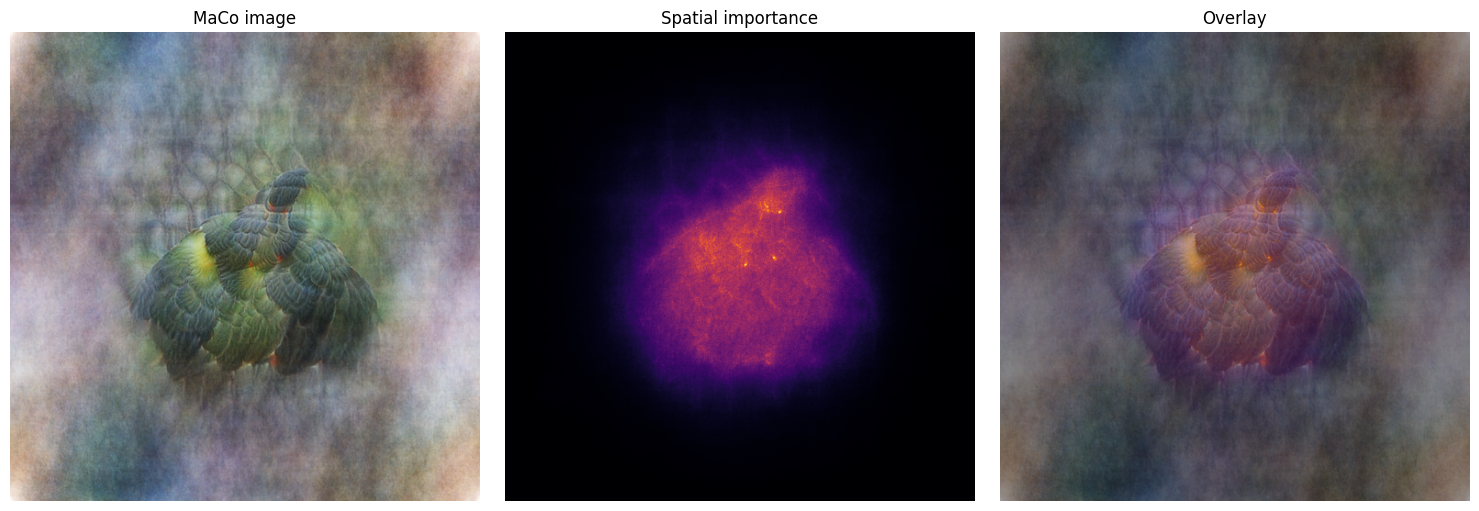

saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_outputs/dreamlens_maco_notebook/toucan_maco_512.png
saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_outputs/dreamlens_maco_notebook/toucan_maco_importance_512.png
saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_outputs/dreamlens_maco_notebook/toucan_maco_panel.png


In [7]:
image_path = OUTPUT_DIR / IMAGE_FILENAME
importance_path = OUTPUT_DIR / IMPORTANCE_FILENAME
panel_path = OUTPUT_DIR / PANEL_FILENAME
result.save(image_path)
result.save_transparency(importance_path)

importance = result.transparency_chw().abs().mean(dim=0)
importance = importance - importance.amin()
importance = importance / importance.amax().clamp_min(1e-12)

figure, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(result.as_hwc().clamp(0, 1))
axes[0].set_title("MaCo image")
axes[1].imshow(importance, cmap="inferno")
axes[1].set_title("Spatial importance")
axes[2].imshow(result.as_hwc().clamp(0, 1))
axes[2].imshow(importance, cmap="inferno", alpha=0.40)
axes[2].set_title("Overlay")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
figure.savefig(panel_path, dpi=140, bbox_inches="tight")
plt.show()
print("saved:", image_path)
print("saved:", importance_path)
print("saved:", panel_path)

## 7. Clean target-score check

This score uses the final image without stochastic crops. It is a diagnostic, not the MaCo training objective averaged across crops.

In [8]:
image = result.as_nchw(device=DEVICE).clamp(0, 1)
image = F.interpolate(
    image,
    size=(MODEL_INPUT_SIZE, MODEL_INPUT_SIZE),
    mode="bilinear",
    align_corners=False,
)
with torch.no_grad():
    clean_logit = float(model(imagenet_preprocess(image))[0, TARGET_CLASS].cpu())
print("clean toucan logit:", clean_logit)

clean toucan logit: 6.819263935089111


## API recap

```python
target = FeatureTarget.for_class(96, layer="fc")
config = MacoConfig(
    width=512,
    height=512,
    input_shape=(3, 224, 224),
    steps=128,
    crops=8,
    lr=1.0,
)
result = visualizer.visualize(target, method="maco", config=config)
result.save("maco.png")
result.save_transparency("importance.png")
```

Use `FeatureTarget.for_layer`, `for_channel`, `for_neuron`, or `for_direction` to change target type without changing the MaCo call.